### **Malaysian Food Sentiment Analysis:** - Model Training
**Models choosen:** Naive Bayes and LSTM

This model_training.ipynb covers:
1. Data loading & Exploration
2. Text preprocessing (stopword removal & stemming)
3. Train / validation/ test split
4. Model training - *Naive bayes & LSTM*
5. Model evaluation & comparison
6. Visualization
7. Best model selection
8. Model saving
9. Reusable prediction function
10. Export artefacts

All saved artefacts are production-ready for loading inside Apache Spark structured streaming

## 0. Environment Setup & Imports

In [52]:
import os, warnings, random
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

# for model 1 (naive bayes)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# for model 2 (LSTM)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

import joblib
import shutil

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("✅ All libraries loaded successfully.")
print(f"   TensorFlow version : {tf.__version__}")
print(f"   Scikit-learn version: {__import__('sklearn').__version__}")
print(f"   Pandas version     : {pd.__version__}")

✅ All libraries loaded successfully.
   TensorFlow version : 2.20.0
   Scikit-learn version: 1.6.1
   Pandas version     : 2.2.2


## 1. Data Loading

In [53]:
df = pd.read_csv('data/labeled_comments_clean.csv')
df.dropna(subset=['comment', 'label'], inplace=True)
df = df[df['comment'].str.strip() != '']
df.reset_index(drop=True, inplace=True)
print("Here's a sample of the data we will use for modeling:")
display(df.head())

Here's a sample of the data we will use for modeling:


,comment,label
0,i know everyone in malaysia that can cook one ...,2
1,is there a crispy crust?,1
2,those bones i cant deal with,0
3,try satay bro,1
4,my fav thing to have in the morning is chapati 😍,2


## 2. Text Preprocessing

In [54]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    text = text.lower()
    words = text.split()
    words = [stemmer.stem(w) for w in words if w not in stop_words]
    return ' '.join(words)

df['processed_text'] = df['comment'].apply(preprocess_text)
dist = df['label'].value_counts()
dist_pct = df['label'].value_counts(normalize=True) * 100

## 3. Train, Validation, Test split

In [55]:
X = df['processed_text'].values
y = df['label'].values

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size = 0.20,
    random_state = SEED,
    stratify = y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size = 0.125,
    random_state = SEED,
    stratify = y_temp
)

## 4. **Model 1:** Naive Bayes Model

              precision    recall  f1-score   support

           0       0.63      0.54      0.58       458
           1       0.68      0.56      0.61       540
           2       0.71      0.85      0.78       902

    accuracy                           0.69      1900
   macro avg       0.68      0.65      0.66      1900
weighted avg       0.69      0.69      0.68      1900



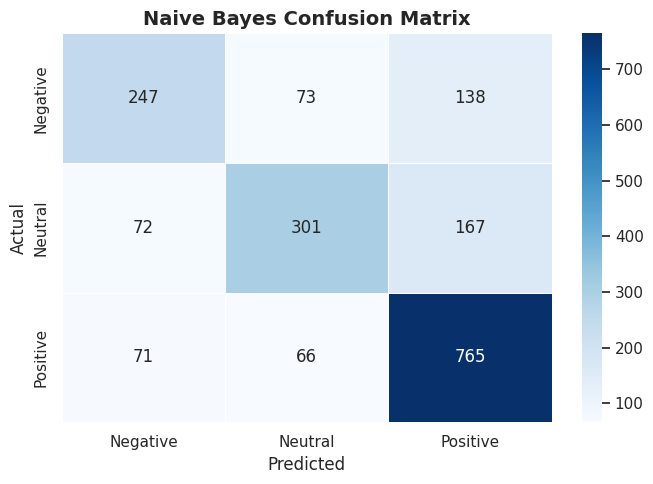

In [56]:
# step 1: TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=10_000,
    ngram_range=(1,2),
    # subliner_tf=True,
    min_df=2,
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

# step 2: train naive bayes
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)

# step 3: evaluate naive bayes
y_pred_nb = nb_model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_nb))

# ── Naive Bayes Confusion Matrix ──────────────────────
cm_nb = confusion_matrix(y_test, y_pred_nb)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'],
            ax=ax, linewidths=0.5, linecolor='white')
ax.set_title('Naive Bayes Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('nb_confusion_matrix.png', dpi=150)
plt.show()

## 5. **Model 2:** LSTM Model

Text length statistics:
count    9499.0
mean       11.9
std        11.2
min         1.0
25%         5.0
50%         9.0
75%        14.0
max       190.0
Name: processed_text, dtype: float64
MAX_LEN=23 | MAX_WORDS=8000
Oversampled train: 9,462 samples
Class weights: {0: np.float64(1.3826159284674568), 1: np.float64(1.1714235377026074), 2: np.float64(0.7027055590784189)}
Train: (9462, 23), Val: (950, 23), Test: (1900, 23)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_4             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


 Training LSTM...
Epoch 1/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.4011 - loss: 1.1089 - val_accuracy: 0.4768 - val_loss: 1.0291 - learning_rate: 5.0000e-04
Epoch 2/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.6972 - loss: 0.7593 - val_accuracy: 0.6747 - val_loss: 0.7720 - learning_rate: 5.0000e-04
Epoch 3/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.8090 - loss: 0.5331 - val_accuracy: 0.7095 - val_loss: 0.7185 - learning_rate: 5.0000e-04
Epoch 4/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.8676 - loss: 0.3947 - val_accuracy: 0.7305 - val_loss: 0.7143 - learning_rate: 5.0000e-04
Epoch 5/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.9005 - loss: 0.3151 - val_accuracy: 0.7326 - val_loss: 0.7424 - learning_rate: 5.0000e-04
Epoch 6/30
296/296 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.9175 - loss: 0.2561 - val_accuracy: 0.7326 - val_loss: 0.7634 - learning_rate: 5.0000e-04
Epoch 7/30
296/296 ━━━━━━━━━━━━━━━━━━

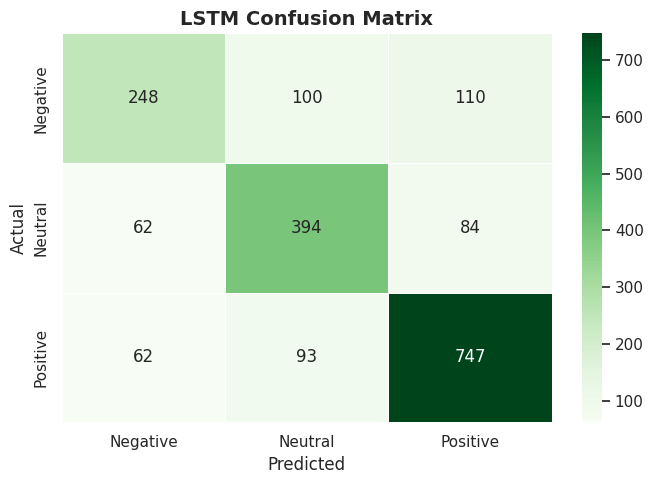

In [57]:
# step 1: text length analysis
text_lengths = df['processed_text'].apply(lambda x: len(str(x).split()))
print("Text length statistics:")
print(text_lengths.describe().round(1))
MAX_LEN = max(15, int(text_lengths.quantile(0.90)))
MAX_WORDS = 8_000
EMBED_DIM = 32
LSTM_UNITS = 64
BATCH_SIZE = 32
EPOCHS = 30
print(f"MAX_LEN={MAX_LEN} | MAX_WORDS={MAX_WORDS}")

# step 2: class balancing (oversampling)
X_over = list(X_train)
y_over = list(y_train)

max_count = np.bincount(y_train).max()

for cls_idx in range(3):
    cls_mask = np.where(y_train == cls_idx)[0]
    cls_count = len(cls_mask)
    n_needed = max_count - cls_count
    if n_needed > 0:
        extra_idx = np.random.choice(cls_mask, size=n_needed, replace=True)
        X_over.extend(X_train[extra_idx])
        y_over.extend(y_train[extra_idx])

X_train_bal = np.array(X_over)
y_train_bal = np.array(y_over)

shuffle_idx = np.random.permutation(len(y_train_bal))
X_train_bal = X_train_bal[shuffle_idx]
y_train_bal = y_train_bal[shuffle_idx]

print(f"Oversampled train: {len(y_train_bal):,} samples")

# step 3: class weights
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_arr))
print("Class weights:", class_weight_dict)

# step 4: tokenization
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_bal)

def encode(texts_arr):
    seqs = tokenizer.texts_to_sequences(texts_arr)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='pre', truncating='post')

X_seq_train = encode(X_train_bal)
X_seq_val = encode(X_val)
X_seq_test = encode(X_test)

y_train_oh = to_categorical(y_train_bal, 3)
y_val_oh = to_categorical(y_val, 3)

print(f"Train: {X_seq_train.shape}, Val: {X_seq_val.shape}, Test: {X_seq_test.shape}")

# step 5: build LSTM model
def build_lstm(vocab_size, embed_dim, lstm_units, num_classes, max_len):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len),
        SpatialDropout1D(0.2),
        LSTM(lstm_units, dropout=0.3, recurrent_dropout=0.2),
        Dense(32, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        metrics=['accuracy']
    )
    return model

lstm_model = build_lstm(MAX_WORDS, EMBED_DIM, LSTM_UNITS, 3, MAX_LEN)
lstm_model.summary()

# step 6: train LSTM
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
]

print("\n Training LSTM...")
history = lstm_model.fit(
    X_seq_train, y_train_oh,
    validation_data=(X_seq_val, y_val_oh),
    class_weight=class_weight_dict,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)
print("✅ LSTM training complete.")

# step 7: evaluate LSTM
y_pred_lstm_prob = lstm_model.predict(X_seq_test)
y_pred_lstm = np.argmax(y_pred_lstm_prob, axis=1)

print("\n📋 LSTM Classification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=['Negative', 'Neutral', 'Positive']))

# ── LSTM Confusion Matrix ─────────────────────────────
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'],
            ax=ax, linewidths=0.5, linecolor='white')
ax.set_title('LSTM Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('lstm_confusion_matrix.png', dpi=150)
plt.show()

## 6. Model comparison


📊 Model Comparison Table
             Accuracy  Precision  Recall  F1-Score
Model                                             
Naive Bayes    0.6911     0.6865  0.6911    0.6833
LSTM           0.7311     0.7283  0.7311    0.7276


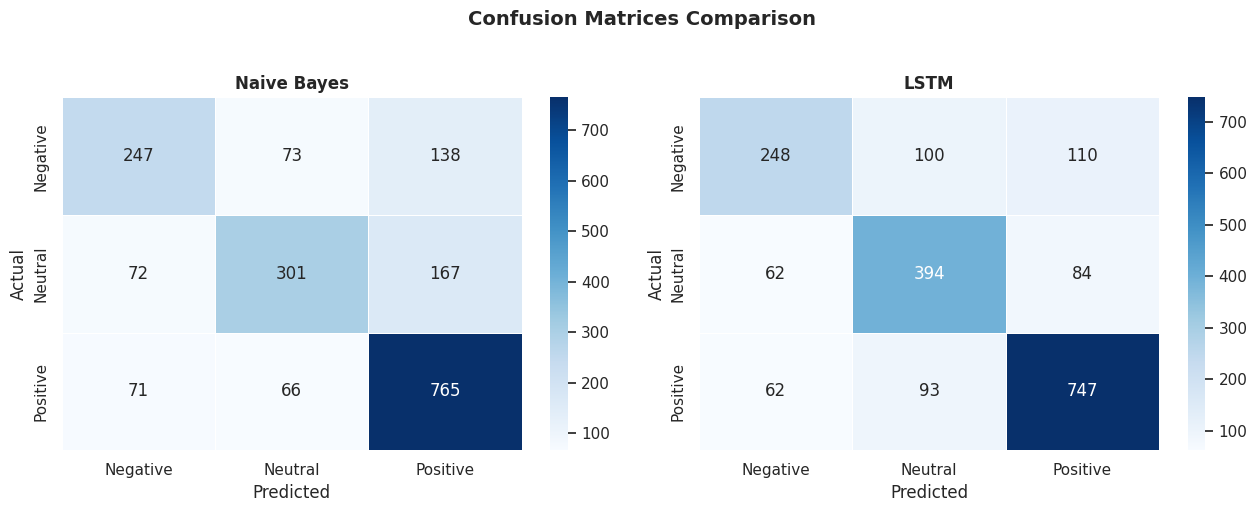

In [58]:
def compute_metrics(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'Recall': round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'F1-Score': round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
    }

results = [
    compute_metrics(y_test, y_pred_nb, 'Naive Bayes'),
    compute_metrics(y_test, y_pred_lstm, 'LSTM'),
]

comparison_df = pd.DataFrame(results).set_index('Model')
print("\n📊 Model Comparison Table")
print(comparison_df.to_string())

# ── Side-by-side Confusion Matrices ────────────────────
def plot_confusion(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Negative', 'Neutral', 'Positive'],
        yticklabels=['Negative', 'Neutral', 'Positive'],
        ax=ax, linewidths=0.5, linecolor='white'
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_confusion(y_test, y_pred_nb,   'Naive Bayes', axes[0])
plot_confusion(y_test, y_pred_lstm, 'LSTM',        axes[1])

plt.suptitle('Confusion Matrices Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Best model selection

In [59]:
best_model_name = comparison_df['F1-Score'].idxmax()
best_f1 = comparison_df.loc[best_model_name, 'F1-Score']

print("\n" + "="*50)
print(f"🏆 Best Model  : {best_model_name}")
print(f"   F1-Score    : {best_f1:.4f}")
print(f"   Accuracy    : {comparison_df.loc[best_model_name, 'Accuracy']:.4f}")
print("="*50)


🏆 Best Model  : LSTM
   F1-Score    : 0.7276
   Accuracy    : 0.7311


## 8. Model saving

In [60]:
import os
os.makedirs('saved_models', exist_ok=True)

# Save Naive Bayes artefacts
joblib.dump(tfidf, 'saved_models/tfidf_vectorizer.pkl')
joblib.dump(nb_model, 'saved_models/nb_model.pkl')
print("✅ Saved: tfidf_vectorizer.pkl, nb_model.pkl")

# Save LSTM artefacts
lstm_model.save('saved_models/lstm_model.keras')
joblib.dump(tokenizer, 'saved_models/lstm_tokenizer.pkl')
lstm_config = {'MAX_LEN': MAX_LEN, 'MAX_WORDS': MAX_WORDS}
joblib.dump(lstm_config, 'saved_models/lstm_config.pkl')
print("✅ Saved: lstm_model.keras, lstm_tokenizer.pkl, lstm_config.pkl")

# Save best model
if best_model_name == 'Naive Bayes':
    joblib.dump(nb_model, 'saved_models/best_model.pkl')
    print("✅ Saved: best_model.pkl (Naive Bayes)")
else:
    import shutil
    shutil.copy('saved_models/lstm_model.keras', 'saved_models/best_model.keras')
    print("✅ Saved: best_model.keras (LSTM)")

# Save comparison and predictions
comparison_df.to_csv('saved_models/model_comparison.csv')
predictions_df = pd.DataFrame({
    'text': X_test,
    'true_sentiment': ['negative' if x==0 else 'neutral' if x==1 else 'positive' for x in y_test],
    'nb_predicted': ['negative' if x==0 else 'neutral' if x==1 else 'positive' for x in y_pred_nb],
    'lstm_predicted': ['negative' if x==0 else 'neutral' if x==1 else 'positive' for x in y_pred_lstm],
})
predictions_df.to_csv('saved_models/predictions.csv', index=False)
print("✅ Saved: model_comparison.csv, predictions.csv")

print("\n📁 All artefacts saved in ./saved_models/")

✅ Saved: tfidf_vectorizer.pkl, nb_model.pkl
✅ Saved: lstm_model.keras, lstm_tokenizer.pkl, lstm_config.pkl
✅ Saved: best_model.keras (LSTM)
✅ Saved: model_comparison.csv, predictions.csv

📁 All artefacts saved in ./saved_models/


## 9. Prediction function

In [61]:
_best_is_lstm = best_model_name == 'LSTM'
if _best_is_lstm:
    _best_model = lstm_model
else:
    _best_model = nb_model
_tfidf = tfidf
_tokenizer = tokenizer
_MAX_LEN = MAX_LEN

def predict_sentiment(text: str) -> str:
    if not isinstance(text, str) or text.strip() == '':
        return 'neutral'

    text = preprocess_text(text)

    if _best_is_lstm:
        seq = _tokenizer.texts_to_sequences([text])
        padded = pad_sequences(seq, maxlen=_MAX_LEN, padding='pre', truncating='post')
        probs = _best_model.predict(padded, verbose=0)
        pred_id = int(np.argmax(probs, axis=1)[0])
    else:
        vec = _tfidf.transform([text])
        pred_id = int(_best_model.predict(vec)[0])

    return ['negative', 'neutral', 'positive'][pred_id]

# Test prediction
print("\n🧪 Testing prediction function:")
test_texts = [
    "I absolutely love this food!",
    "The service was okay, nothing special.",
    "Terrible experience, would not recommend."
]
for text in test_texts:
    print(f"  '{text[:40]}' → {predict_sentiment(text)}")


🧪 Testing prediction function:
  'I absolutely love this food!' → positive
  'The service was okay, nothing special.' → neutral
  'Terrible experience, would not recommend' → negative
